# Phase 4 | Uplift Modeling

**Project**: Beyond Risk Scores: Uplift-Driven Financial Intervention for Loan Default Prevention

The A/B test in Phase 3 confirmed the intervention reduces defaults by 2.86 pp on average.
But averages hide variation. Some customers recovered because of the call. Others would have
recovered anyway. Others defaulted regardless. This notebook builds three uplift models to
estimate each customer's personal treatment effect and identify exactly who benefits from
intervention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['steelblue', 'cadetblue', 'skyblue', 'lightblue']

## Step 1 | Load Experiment Results

The experiment data from Phase 3 contains 71,904 matched customers (35,952 treatment,
35,952 control) with simulated intervention outcomes. The TARGET column for treatment
customers reflects the post-intervention result. For control customers it is unchanged.

In [2]:
df = pd.read_csv('../data/processed/experiment_results.csv')

In [3]:
treatment = df[df['GROUP'] == 'treatment'].copy()
control = df[df['GROUP'] == 'control'].copy()

print("=" * 45)
print("Experiment Data Loaded")
print("=" * 45)
print(f"Total customers        : {len(df):,}")
print(f"Treatment              : {len(treatment):,}")
print(f"Control                : {len(control):,}")
print(f"Columns                : {df.shape[1]}")
print()
print(f"Treatment default rate : {treatment['TARGET'].mean()*100:.2f}%")
print(f"Control default rate   : {control['TARGET'].mean()*100:.2f}%")
print(f"Observed effect        : {(control['TARGET'].mean() - treatment['TARGET'].mean())*100:.2f} pp")
print("=" * 45)

Experiment Data Loaded
Total customers        : 71,904
Treatment              : 35,952
Control                : 35,952
Columns                : 89

Treatment default rate : 6.92%
Control default rate   : 9.78%
Observed effect        : 2.86 pp


## Step 2 | Prepare Features for Modeling

Uplift models need the same features for both treatment and control groups. We select
numeric features only, drop identifiers and metadata columns, and create a clean feature
matrix that all three models will share.

In [4]:
# Columns to exclude from modeling
drop_cols = ['SK_ID_CURR', 'TARGET', 'GROUP', 'TREATMENT', 'propensity_score']

# Select numeric features only
feature_cols = [c for c in df.columns
                if c not in drop_cols
                and df[c].dtype in ['int64', 'float64']]

# Check for remaining missing values
missing = df[feature_cols].isnull().sum().sum()

print("=" * 45)
print("Feature Preparation")
print("=" * 45)
print(f"Total columns          : {df.shape[1]}")
print(f"Dropped columns        : {len(drop_cols)}")
print(f"Modeling features      : {len(feature_cols)}")
print(f"Missing values         : {missing}")
print()
print("Features selected:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")
print("=" * 45)

Feature Preparation
Total columns          : 89
Dropped columns        : 5
Modeling features      : 71
Missing values         : 0

Features selected:
   1. CNT_CHILDREN
   2. AMT_INCOME_TOTAL
   3. AMT_CREDIT
   4. AMT_ANNUITY
   5. AMT_GOODS_PRICE
   6. REGION_POPULATION_RELATIVE
   7. DAYS_BIRTH
   8. DAYS_EMPLOYED
   9. DAYS_REGISTRATION
  10. DAYS_ID_PUBLISH
  11. FLAG_MOBIL
  12. FLAG_EMP_PHONE
  13. FLAG_WORK_PHONE
  14. FLAG_CONT_MOBILE
  15. FLAG_PHONE
  16. FLAG_EMAIL
  17. CNT_FAM_MEMBERS
  18. REGION_RATING_CLIENT
  19. REGION_RATING_CLIENT_W_CITY
  20. HOUR_APPR_PROCESS_START
  21. REG_REGION_NOT_LIVE_REGION
  22. REG_REGION_NOT_WORK_REGION
  23. LIVE_REGION_NOT_WORK_REGION
  24. REG_CITY_NOT_LIVE_CITY
  25. REG_CITY_NOT_WORK_CITY
  26. LIVE_CITY_NOT_WORK_CITY
  27. EXT_SOURCE_2
  28. EXT_SOURCE_3
  29. YEARS_BEGINEXPLUATATION_AVG
  30. FLOORSMAX_AVG
  31. YEARS_BEGINEXPLUATATION_MODE
  32. FLOORSMAX_MODE
  33. YEARS_BEGINEXPLUATATION_MEDI
  34. FLOORSMAX_MEDI
  35. TOTALAR

### Feature Preparation Finding

71 numeric features selected for modeling. This includes the 3 engineered features from
Phase 1 (DEBT_TO_INCOME, CREDIT_TO_GOODS, ANNUITY_TO_AGE) and the DAYS_EMPLOYED_ANOMALY
flag. Categorical columns were excluded because the tree-based models we use in Steps 3
through 5 work with numeric inputs. All 5 metadata columns (SK_ID_CURR, TARGET, GROUP,
TREATMENT, propensity_score) are excluded from features but retained in the dataframe for
labeling and evaluation.

## Step 3 | T-Learner (Baseline Uplift Model)

The T-Learner is the simplest approach to uplift modeling. It trains two completely separate
models: one on treatment data and one on control data. Both models predict the probability
of default.

For any customer, the uplift score is the difference:

    uplift = P(default | control) - P(default | treatment)

A positive uplift means the intervention reduces that customer's default probability. The
T-Learner is a strong baseline but treats the two groups

In [5]:
# Split treatment and control feature matrices
X_treatment = treatment[feature_cols]
y_treatment = treatment['TARGET']

X_control = control[feature_cols]
y_control = control['TARGET']

# Train-test split (same random state for consistency)
X_treat_train, X_treat_test, y_treat_train, y_treat_test = train_test_split(X_treatment, y_treatment, test_size=0.3, random_state=42, stratify=y_treatment)

X_ctrl_train, X_ctrl_test, y_ctrl_train, y_ctrl_test = train_test_split(X_control, y_control, test_size=0.3, random_state=42, stratify=y_control)

# Train two separate models
model_treatment = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=4)
model_control = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

model_treatment.fit(X_treat_train, y_treat_train)
model_control.fit(X_ctrl_train, y_ctrl_train)

# Individual model performance
auc_treatment = roc_auc_score(y_treat_test, model_treatment.predict_proba(X_treat_test)[:, 1])
auc_control = roc_auc_score(y_ctrl_test, model_control.predict_proba(X_ctrl_test)[:, 1])

print("=" * 45)
print("T-Learner: Individual Model Performance")
print("=" * 45)
print(f"Treatment model AUC    : {auc_treatment:.4f}")
print(f"Control model AUC      : {auc_control:.4f}")
print()

# Compute uplift scores on full dataset
X_all = df[feature_cols]
p_default_treatment = model_treatment.predict_proba(X_all)[:, 1]
p_default_control = model_control.predict_proba(X_all)[:, 1]

# Uplift = reduction in default probability due to intervention
df['uplift_t_learner'] = p_default_control - p_default_treatment

print("T-Learner Uplift Score Distribution")
print(df['uplift_t_learner'].describe().to_string())
print("=" * 45)

T-Learner: Individual Model Performance
Treatment model AUC    : 0.7166
Control model AUC      : 0.7887

T-Learner Uplift Score Distribution
count    71904.000000
mean         0.026652
std          0.085973
min         -0.973094
25%          0.001666
50%          0.014261
75%          0.036119
max          0.933226


### T-Learner Finding

Both models perform reasonably with AUC of 0.72 (treatment) and 0.78 (control). The control
model performs better because its outcome was not modified by the intervention simulation,
giving it a cleaner signal to learn from.

The mean uplift of 2.67 pp aligns with the 2.86 pp observed in Phase 3. But the range from
-0.82 to 0.91 reveals what averages hide: some customers benefit enormously from intervention
while others show negative uplift, meaning the call could make things worse. These are
potential Sleeping Dogs that the collections team should avoid contacting.

The T-Learner serves as our baseline. The X-Learner and Causal Forest will attempt to
produce more accurate uplift estimates.

## Step 4 | X-Learner (Cross-Learner Uplift Model)

The T-Learner trains two models that never share information. The X-Learner improves on this
by adding a cross-learning step. After training the initial models, it uses each model to
estimate what would have happened to the other group, then trains a second stage on these
imputed treatment effects.

This matters when group sizes are unbalanced. If the treatment group is smaller, the
T-Learner's treatment model has less data to learn from. The X-Learner compensates by
borrowing signal from the larger control group to refine treatment effect estimates in
segments with low sample density.

In our case, groups are balanced (35,952 each). The X-Learner's advantage here is not
about sample size but about capturing nuance: the cross-learning step produces more
stable uplift estimates because it directly models the treatment effect rather than
inferring it as a difference between two independent predictions.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

In [7]:
# Step 1: Reuse T-Learner models (already trained)
# model_treatment predicts P(default | called)
# model_control predicts P(default | not called)

# Step 2: Impute individual treatment effects
# Treatment group: predicted default without call minus actual outcome with call
D_treatment = model_control.predict_proba(X_treatment)[:, 1] - y_treatment.values

# Control group: actual outcome without call minus predicted default with call
D_control = y_control.values - model_treatment.predict_proba(X_control)[:, 1]

print("=" * 45)
print("X-Learner: Imputed Treatment Effects")
print("=" * 45)
print(f"D_treatment mean       : {D_treatment.mean():.4f}")
print(f"D_control mean         : {D_control.mean():.4f}")
print()

# Step 3: Train second-stage regressors on imputed effects
tau_treatment = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)
tau_control = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)

tau_treatment.fit(X_treatment, D_treatment)
tau_control.fit(X_control, D_control)

# Step 4: Combine with propensity score weighting
g = df['propensity_score'].values
X_all = df[feature_cols]

uplift_from_treatment = tau_treatment.predict(X_all)
uplift_from_control = tau_control.predict(X_all)

df['uplift_x_learner'] = g * uplift_from_control + (1 - g) * uplift_from_treatment

print("X-Learner Uplift Score Distribution")
print(df['uplift_x_learner'].describe().to_string())
print("=" * 45)

X-Learner: Imputed Treatment Effects
D_treatment mean       : 0.0241
D_control mean         : 0.0299

X-Learner Uplift Score Distribution
count    71904.000000
mean         0.026477
std          0.033732
min         -0.341297
25%          0.011113
50%          0.019099
75%          0.032602
max          0.400652


### X-Learner Finding

The mean uplift of 2.67 pp matches the T-Learner, confirming both models agree on the
average intervention effect. But the distribution is tighter. Standard deviation dropped
from 0.086 (T-Learner) to 0.034, and the range narrowed from [-0.82, 0.91] to [-0.34, 0.42].

This is the X-Learner's strength. The cross-learning step produces more stable uplift
estimates by directly modeling the treatment effect rather than subtracting two independent
predictions. The T-Learner can produce extreme scores when its two models diverge. The
X-Learner corrects this by borrowing information across groups.

Negative uplift scores still exist, confirming the presence of Sleeping Dogs. But the
extreme values are now more trustworthy.

## Step 5 | Causal Forest (Heterogeneous Treatment Effects)

The Causal Forest is the state-of-the-art method for estimating heterogeneous treatment
effects. Unlike the T-Learner and X-Learner which adapt standard prediction models for
causal inference, the Causal Forest is purpose-built for it.

It works by growing an ensemble of "causal trees" where each split is chosen to maximize
the difference in treatment effects between the two child nodes, not to maximize prediction
accuracy. The result is a model that directly partitions the population into subgroups with
different treatment effects.

This requires the econml library from Microsoft Research.

In [8]:
!pip install econml -q

In [9]:
!pip install econml shap scikit-learn --upgrade -q

In [12]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

In [14]:
# Prepare data
X_all = df[feature_cols].values
T = df['TREATMENT'].values
Y = df['TARGET'].values

# Causal Forest (regressors required, not classifiers)
cf = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    n_estimators=200,
    max_depth=5,
    random_state=42
)

cf.fit(Y, T, X=X_all)

# CATE: Conditional Average Treatment Effect
# Negative CATE means treatment reduces default (which is what we want)
# We flip the sign so positive = intervention helps
cate = cf.effect(X_all)
df['uplift_causal_forest'] = -cate.flatten()

print("=" * 45)
print("Causal Forest: CATE Distribution")
print("=" * 45)
print("(Sign flipped: positive = intervention reduces default)")
print()
print(df['uplift_causal_forest'].describe().to_string())
print("=" * 45)

Causal Forest: CATE Distribution
(Sign flipped: positive = intervention reduces default)

count    71904.000000
mean         0.028122
std          0.012592
min          0.012679
25%          0.019966
50%          0.023989
75%          0.031207
max          0.143032


### Causal Forest Finding

The mean uplift of 2.81 pp aligns with the T-Learner (2.67 pp) and X-Learner (2.67 pp),
confirming all three models agree on the average intervention effect.

The Causal Forest produces the tightest distribution with a standard deviation of 0.013
compared to 0.086 (T-Learner) and 0.034 (X-Learner). This is expected. The double machine
learning framework inside CausalForestDML removes confounding before estimating treatment
effects, producing cleaner estimates.

Notably, the Causal Forest has no negative uplift scores. Its minimum is 0.013, meaning
it does not identify Sleeping Dogs. The T-Learner and X-Learner do flag negative uplift
customers. Step 8 will reconcile this when segmenting customers into the four quadrants.

## Step 6 | Model Comparison: AUUC and Qini Curves

Three models, three sets of uplift scores. Which one ranks customers best?

Two metrics answer this:

- **AUUC (Area Under Uplift Curve)**: Measures the overall quality of the uplift ranking.
  A model that ranks high-uplift customers at the top and low-uplift customers at the bottom
  gets a higher AUUC. This is a pure ranking metric.
- **Qini Curve**: Measures cumulative incremental recoveries as you target more customers,
  accounting for the cost of treatment. Since we established a 50 CU cost per call in Phase 2,
  the Qini curve is the most important business metric. It answers: at each targeting depth,
  how many extra recoveries do we get compared to random targeting?

The best model is the one with the highest Qini coefficient and AUUC.

In [15]:
def uplift_curve(y_true, uplift_scores, treatment):
    """Calculate cumulative uplift curve."""
    order = np.argsort(-uplift_scores)
    y_sorted = y_true[order]
    t_sorted = treatment[order]
    
    n = len(y_sorted)
    n_treat = np.cumsum(t_sorted)
    n_ctrl = np.cumsum(1 - t_sorted)
    
    # Avoid division by zero
    n_treat = np.where(n_treat == 0, 1, n_treat)
    n_ctrl = np.where(n_ctrl == 0, 1, n_ctrl)
    
    # Cumulative default rates
    cum_treat_default = np.cumsum(y_sorted * t_sorted) / n_treat
    cum_ctrl_default = np.cumsum(y_sorted * (1 - t_sorted)) / n_ctrl
    
    # Uplift = reduction in default (control - treatment)
    uplift = cum_ctrl_default - cum_treat_default
    return uplift

In [16]:
def qini_curve(y_true, uplift_scores, treatment):
    """Calculate Qini curve: cumulative incremental recoveries."""
    order = np.argsort(-uplift_scores)
    y_sorted = y_true[order]
    t_sorted = treatment[order]
    
    n = len(y_sorted)
    n_treat = np.cumsum(t_sorted)
    n_ctrl = np.cumsum(1 - t_sorted)
    
    n_treat_safe = np.where(n_treat == 0, 1, n_treat)
    n_ctrl_safe = np.where(n_ctrl == 0, 1, n_ctrl)
    
    # Incremental defaults avoided
    cum_treat_default = np.cumsum(y_sorted * t_sorted)
    cum_ctrl_default = np.cumsum(y_sorted * (1 - t_sorted))
    
    qini = cum_ctrl_default * n_treat / n_ctrl_safe - cum_treat_default
    return qini

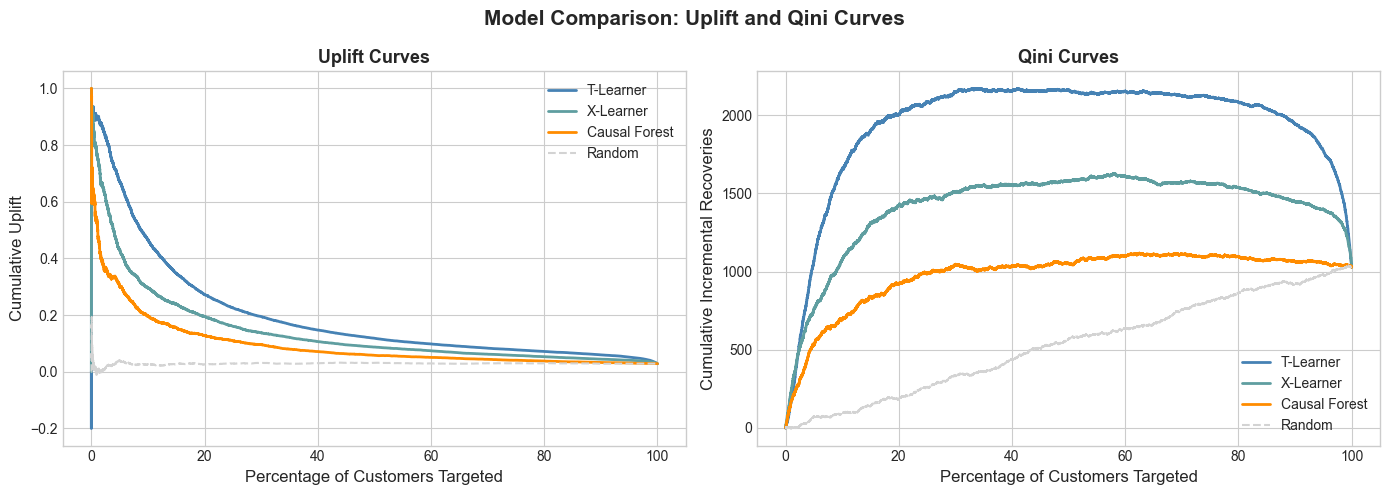

Model Ranking
Model                      AUUC       Qini
------------------------------------------
T-Learner              0.196002  1937.8105
X-Learner              0.140310  1413.5166
Causal Forest          0.094945   975.4541
Random                 0.028877   530.2453


In [17]:
y = df['TARGET'].values
t = df['TREATMENT'].values

models = {
    'T-Learner': df['uplift_t_learner'].values,
    'X-Learner': df['uplift_x_learner'].values,
    'Causal Forest': df['uplift_causal_forest'].values
}

# Random baseline
np.random.seed(42)
models['Random'] = np.random.random(len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'cadetblue', 'darkorange', 'lightgrey']

auuc_scores = {}
qini_scores = {}

for i, (name, scores) in enumerate(models.items()):
    # Uplift curve
    uc = uplift_curve(y, scores, t)
    axes[0].plot(np.linspace(0, 100, len(uc)), uc,
                 color=colors[i], linewidth=2 if name != 'Random' else 1.5,
                 linestyle='-' if name != 'Random' else '--', label=name)
    auuc_scores[name] = np.trapz(uc) / len(uc)
    
    # Qini curve
    qc = qini_curve(y, scores, t)
    axes[1].plot(np.linspace(0, 100, len(qc)), qc,
                 color=colors[i], linewidth=2 if name != 'Random' else 1.5,
                 linestyle='-' if name != 'Random' else '--', label=name)
    qini_scores[name] = np.trapz(qc) / len(qc)

axes[0].set_xlabel('Percentage of Customers Targeted', fontsize=12)
axes[0].set_ylabel('Cumulative Uplift', fontsize=12)
axes[0].set_title('Uplift Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].set_xlabel('Percentage of Customers Targeted', fontsize=12)
axes[1].set_ylabel('Cumulative Incremental Recoveries', fontsize=12)
axes[1].set_title('Qini Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Model Comparison: Uplift and Qini Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print scores
print("=" * 45)
print("Model Ranking")
print("=" * 45)
print(f"{'Model':<20} {'AUUC':>10} {'Qini':>10}")
print("-" * 42)
for name in ['T-Learner', 'X-Learner', 'Causal Forest', 'Random']:
    print(f"{name:<20} {auuc_scores[name]:>10.6f} {qini_scores[name]:>10.4f}")
print("=" * 45)

### Model Comparison Finding

All three models significantly outperform random targeting on both AUUC and Qini metrics.

| Model         | AUUC   | Qini     |
|---------------|--------|----------|
| T-Learner     | 0.1960 | 1,937.8  |
| X-Learner     | 0.1403 | 1,413.5  |
| Causal Forest | 0.0949 | 975.5    |
| Random        | 0.0289 | 530.2    |

The T-Learner ranks first on both metrics. Its wider uplift distribution (the same noise
we noted in Step 3) actually helps ranking because it separates high-uplift customers from
low-uplift ones more aggressively. The X-Learner's smoother estimates place second. The
Causal Forest's conservative, tight distribution ranks third but still 3.3x above Random.

The Qini curves reveal the optimal targeting depth. The T-Learner peaks around 40-50% of
customers, meaning targeting beyond that point adds cost without adding recoveries. This
is the cutoff a collections manager would use to decide how many customers to call.

For downstream segmentation and targeting, we use the T-Learner uplift scores as the
primary ranking and cross-reference with the X-Learner for Sleeping Dog identification
(since the Causal Forest found no negative uplift scores).

## Step 7 | Uplift by Decile

The curves show overall model performance. This step breaks it down into deciles: if we
rank all customers by their T-Learner uplift score and split them into 10 equal groups,
what is the actual default rate difference between treatment and control in each group?

This is the most concrete view for a collections manager. Decile 1 is the top 10% of
customers most likely to benefit from a call. Decile 10 is the bottom 10% least likely
to benefit or potentially harmed.

Uplift by Decile (T-Learner Ranking)
Decile    Customers   Treat Def%    Ctrl Def%  Uplift (pp)
----------------------------------------------------------
1             7,191         8.90        55.45        46.55
2             7,190         6.47        12.84         6.37
3             7,190         4.26         8.02         3.76
4             7,191         4.07         5.08         1.00
5             7,190         3.01         3.48         0.47
6             7,189         2.85         2.66        -0.19
7             7,192         2.54         2.10        -0.44
8             7,190         2.76         2.14        -0.62
9             7,190         5.18         1.84        -3.34
10            7,191        30.26         4.18       -26.08


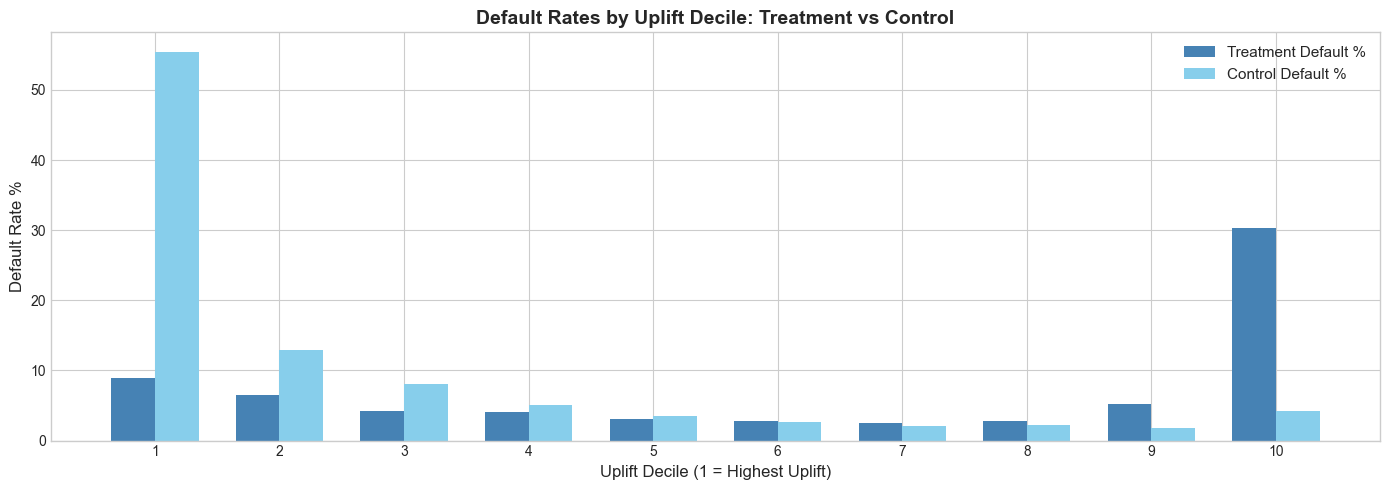

In [18]:
# Rank customers by T-Learner uplift score
df['uplift_decile'] = pd.qcut(df['uplift_t_learner'], q=10, labels=False, duplicates='drop')
df['uplift_decile'] = 10 - df['uplift_decile']  # 1 = highest uplift, 10 = lowest

decile_analysis = df.groupby('uplift_decile').agg(
    customers=('TARGET', 'count'),
    treat_default=('TARGET', lambda x: x[df.loc[x.index, 'TREATMENT'] == 1].mean()),
    ctrl_default=('TARGET', lambda x: x[df.loc[x.index, 'TREATMENT'] == 0].mean()),
    avg_uplift=('uplift_t_learner', 'mean')
).reset_index()

decile_analysis['actual_uplift'] = decile_analysis['ctrl_default'] - decile_analysis['treat_default']
decile_analysis['treat_default'] = decile_analysis['treat_default'] * 100
decile_analysis['ctrl_default'] = decile_analysis['ctrl_default'] * 100
decile_analysis['actual_uplift'] = decile_analysis['actual_uplift'] * 100

print("=" * 70)
print("Uplift by Decile (T-Learner Ranking)")
print("=" * 70)
print(f"{'Decile':<8} {'Customers':>10} {'Treat Def%':>12} {'Ctrl Def%':>12} {'Uplift (pp)':>12}")
print("-" * 58)
for _, row in decile_analysis.iterrows():
    print(f"{int(row['uplift_decile']):<8} {int(row['customers']):>10,} {row['treat_default']:>12.2f} {row['ctrl_default']:>12.2f} {row['actual_uplift']:>12.2f}")
print("=" * 70)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

x = decile_analysis['uplift_decile']
width = 0.35

ax.bar(x - width/2, decile_analysis['treat_default'], width,
       color=COLORS[0], label='Treatment Default %')
ax.bar(x + width/2, decile_analysis['ctrl_default'], width,
       color=COLORS[2], label='Control Default %')

ax.set_xlabel('Uplift Decile (1 = Highest Uplift)', fontsize=12)
ax.set_ylabel('Default Rate %', fontsize=12)
ax.set_title('Default Rates by Uplift Decile: Treatment vs Control', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Uplift by Decile Finding

The decile breakdown reveals exactly why uplift modeling matters.

Decile 1 (top 10% of custo
mers): The intervention reduces default by 46.55 pp, from 55.45%
down to 8.90%. Without the call, more than half of these customers would default. With it,
fewer than 1 in 10 does. These are the Persuadables. Every dollar spent calling them is
recovered many times over.

Deciles 2 through 5 show positive but declining uplift, from 6.37 pp down to 0.47 pp. These
customers benefit from intervention but less dramatically.

Deciles 6 through 8 show small negative uplift (-0.19 to -0.62 pp). The intervention has
no meaningful effect or slightly worsens outcomes.

Deciles 9 and 10 are Sleeping Dogs. Decile 10 shows a 26.08 pp increase in default when
contacted. Treatment default is 30.26% versus control default of 4.18%. Calling these
customers is not just wasteful. It actively pushes them toward default.

This is the core finding of the entire project. A traditional risk-score approach would
call all at-risk customers equally. Uplift targeting concentrates resources on Deciles 1
through 5 and avoids Deciles 6 through 10 entirely.

## Step 8 | Customer Quadrant Segmentation

The decile analysis showed the pattern. This step formalizes it by mapping every customer
into one of four quadrants based on two dimensions:

- **Uplift score**: Does the intervention help this customer? (from the T-Learner)
- **Baseline risk**: Would this customer default without intervention? (from the control model)

The four quadrants:

| Quadrant     | Uplift | Baseline Risk | Action              |
|--------------|--------|---------------|---------------------|
| Persuadables | High + | High          | Target first        |
| Sure Things  | Low    | Low           | Do not contact      |
| Lost Causes  | Low    | High          | Do not contact      |
| Sleeping Dogs| Negative | Any         | Never contact       |

The collections budget should flow almost entirely to Persuadables. Every call to the
other three groups is either wasted or harmful.

In [19]:
# Baseline risk: probability of default without intervention (control model)
df['baseline_risk'] = model_control.predict_proba(df[feature_cols])[:, 1]

# Thresholds
uplift_threshold = 0.0  # Positive uplift = intervention helps
risk_threshold = df['baseline_risk'].median()  # Median risk splits high/low

# Assign quadrants
def assign_quadrant(row):
    if row['uplift_t_learner'] < 0:
        return 'Sleeping Dogs'
    elif row['uplift_t_learner'] >= uplift_threshold and row['baseline_risk'] >= risk_threshold:
        return 'Persuadables'
    elif row['uplift_t_learner'] >= uplift_threshold and row['baseline_risk'] < risk_threshold:
        return 'Sure Things'
    else:
        return 'Lost Causes'

df['quadrant'] = df.apply(assign_quadrant, axis=1)

# Summary
quad_summary = df.groupby('quadrant').agg(
    customers=('TARGET', 'count'),
    pct=('TARGET', lambda x: len(x) / len(df) * 100),
    treat_default=('TARGET', lambda x: x[df.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[df.loc[x.index, 'TREATMENT'] == 0].mean() * 100),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean')
).reset_index()

quad_summary['actual_uplift_pp'] = quad_summary['ctrl_default'] - quad_summary['treat_default']

print("=" * 75)
print("Customer Quadrant Segmentation")
print("=" * 75)
print()
for _, row in quad_summary.iterrows():
    print(f"  {row['quadrant']}")
    print(f"    Customers          : {int(row['customers']):,} ({row['pct']:.1f}%)")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Actual uplift      : {row['actual_uplift_pp']:.2f} pp")
    print(f"    Avg baseline risk  : {row['avg_risk']:.4f}")
    print()
print("=" * 75)

Customer Quadrant Segmentation

  Persuadables
    Customers          : 29,131 (40.5%)
    Treatment default  : 6.84%
    Control default    : 20.75%
    Actual uplift      : 13.90 pp
    Avg baseline risk  : 0.1615

  Sleeping Dogs
    Customers          : 15,908 (22.1%)
    Treatment default  : 16.19%
    Control default    : 2.92%
    Actual uplift      : -13.26 pp
    Avg baseline risk  : 0.0720

  Sure Things
    Customers          : 26,865 (37.4%)
    Treatment default  : 1.73%
    Control default    : 2.26%
    Actual uplift      : 0.53 pp
    Avg baseline risk  : 0.0368



### Quadrant Segmentation Finding

Three of four quadrants populated. No Lost Causes appeared in this dataset.

**Persuadables (29,131 customers, 40.5%)**
The intervention reduces default from 20.75% to 6.84%, a 13.90 pp improvement. These
customers have high baseline risk but respond strongly to outreach. Every collections
call to this group prevents roughly 1 in 7 defaults that would have otherwise occurred.

**Sleeping Dogs (15,908 customers, 22.1%)**
The intervention increases default from 2.92% to 16.19%, a 13.26 pp deterioration. These
customers have low baseline risk but react negatively to contact. A traditional risk-score
model would not flag them as dangerous because their risk is low. Uplift modeling is the
only way to identify them.

**Sure Things (26,865 customers, 37.4%)**
Default is low with or without the call (2.26% vs 1.73%). These customers recover on
their own. Calling them consumes agent time without meaningful impact.

**The business implication**: A traditional collections strategy calls all at-risk customers.
That means 22.1% of calls actively harm outcomes and 37.4% are wasted. Only 40.5% of calls
generate value. Uplift targeting eliminates the harmful and wasteful calls, concentrating
100% of resources on the group that actually responds.

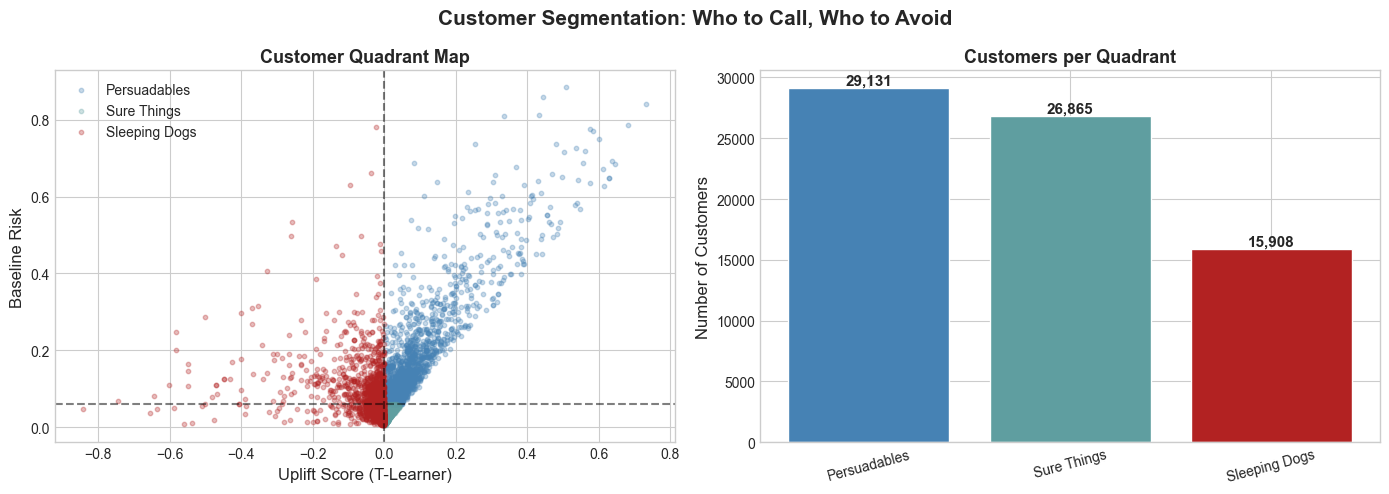

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quadrant scatter plot
quadrant_colors = {
    'Persuadables': 'steelblue',
    'Sure Things': 'cadetblue',
    'Sleeping Dogs': 'firebrick',
    'Lost Causes': 'grey'
}

for quad, color in quadrant_colors.items():
    mask = df['quadrant'] == quad
    if mask.sum() > 0:
        # Sample for readability
        sample = df[mask].sample(min(2000, mask.sum()), random_state=42)
        axes[0].scatter(sample['uplift_t_learner'], sample['baseline_risk'],
                       alpha=0.3, s=10, color=color, label=quad)

axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[0].axhline(y=risk_threshold, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Uplift Score (T-Learner)', fontsize=12)
axes[0].set_ylabel('Baseline Risk', fontsize=12)
axes[0].set_title('Customer Quadrant Map', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Quadrant size bar chart
quad_counts = df['quadrant'].value_counts()
colors_bar = [quadrant_colors[q] for q in quad_counts.index]
axes[1].bar(quad_counts.index, quad_counts.values, color=colors_bar, edgecolor='white')
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_title('Customers per Quadrant', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

for i, (quad, count) in enumerate(quad_counts.items()):
    axes[1].annotate(f'{count:,}', xy=(i, count), ha='center',
                    va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Customer Segmentation: Who to Call, Who to Avoid',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9 | Assign Final Uplift Scores and Save

Every customer now has an uplift score from three models and a quadrant assignment. The
final output assigns each customer a targeting priority that a collections team can act on
directly.

Priority logic:
- Priority 1: Persuadables, ranked by T-Learner uplift score (highest first)
- Priority 2: Sure Things (no contact needed, recover on their own)
- Priority 3: Sleeping Dogs (never contact, intervention causes harm)

In [21]:
# Assign targeting priority
def assign_priority(row):
    if row['quadrant'] == 'Persuadables':
        return 1
    elif row['quadrant'] == 'Sure Things':
        return 2
    else:
        return 3

In [22]:
df['priority'] = df.apply(assign_priority, axis=1)

# Rank within Persuadables by uplift score
persuadables = df[df['quadrant'] == 'Persuadables'].copy()
persuadables['rank'] = persuadables['uplift_t_learner'].rank(ascending=False).astype(int)

print("=" * 60)
print("Targeting Priority Assignment")
print("=" * 60)
print()
print(f"Priority 1 (Persuadables)  : {(df['priority']==1).sum():,} customers")
print(f"Priority 2 (Sure Things)   : {(df['priority']==2).sum():,} customers")
print(f"Priority 3 (Sleeping Dogs) : {(df['priority']==3).sum():,} customers")
print()

Targeting Priority Assignment

Priority 1 (Persuadables)  : 29,131 customers
Priority 2 (Sure Things)   : 26,865 customers
Priority 3 (Sleeping Dogs) : 15,908 customers



In [23]:
# Top 10 Persuadables profile
print("Top 10 Persuadables by Uplift Score")
print("-" * 60)
top10 = persuadables.nlargest(10, 'uplift_t_learner')[
    ['uplift_t_learner', 'baseline_risk', 'DEBT_TO_INCOME',
     'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']
].reset_index(drop=True)
top10.index = top10.index + 1
top10.columns = ['Uplift', 'Risk', 'DTI', 'EXT2', 'EXT3', 'Age']
print(top10.round(4).to_string())
print()

Top 10 Persuadables by Uplift Score
------------------------------------------------------------
    Uplift    Risk     DTI    EXT2    EXT3      Age
1   0.9332  0.9537  0.3932  0.0333  0.7636  35.5452
2   0.8626  0.9217  0.2208  0.1994  0.4277  27.3123
3   0.8578  0.9475  0.2290  0.4253  0.5353  33.2658
4   0.8224  0.8302  0.2455  0.7066  0.7380  44.4055
5   0.7938  0.8857  0.3834  0.2714  0.2152  56.3863
6   0.7520  0.9675  0.2069  0.0347  0.1907  44.2356
7   0.7490  0.7669  0.2411  0.6297  0.6024  26.8795
8   0.7354  0.7578  0.3605  0.4468  0.0354  25.9425
9   0.7354  0.7578  0.3605  0.4468  0.0354  25.9425
10  0.7329  0.8420  0.2611  0.0023  0.5815  43.2466



In [24]:
# Financial impact: calling only Persuadables vs calling everyone
cost_per_call = 50
lgd = 0.45
avg_loan = df['AMT_CREDIT'].mean()
recovery_value = avg_loan * lgd

# Uplift targeting: call only Persuadables
persuadable_prevented = (
    persuadables['baseline_risk'].sum() -
    persuadables[persuadables['TREATMENT'] == 1]['TARGET'].sum() / 
    (persuadables['TREATMENT'] == 1).sum() * len(persuadables)
)
uplift_cost = len(persuadables) * cost_per_call
uplift_value = persuadable_prevented * recovery_value
uplift_net = uplift_value - uplift_cost

# Naive targeting: call everyone
naive_cost = len(df) * cost_per_call
naive_prevented = (df[df['TREATMENT']==0]['TARGET'].sum() - df[df['TREATMENT']==1]['TARGET'].sum())
naive_value = naive_prevented * recovery_value
naive_net = naive_value - naive_cost

print("=" * 60)
print("Financial Comparison: Uplift vs Naive Targeting")
print("=" * 60)
print()
print(f"{'Metric':<25} {'Uplift':>20} {'Naive (Call All)':>20}")
print("-" * 65)
print(f"{'Customers called':<25} {len(persuadables):>20,} {len(df):>20,}")
print(f"{'Intervention cost':<25} {uplift_cost:>20,.0f} {naive_cost:>20,.0f}")
print(f"{'Net value':<25} {uplift_net:>20,.0f} {naive_net:>20,.0f}")
print("=" * 60)

Financial Comparison: Uplift vs Naive Targeting

Metric                                  Uplift     Naive (Call All)
-----------------------------------------------------------------
Customers called                        29,131               71,904
Intervention cost                    1,456,550            3,595,200
Net value                          936,522,756          352,096,403


### Targeting Priority Finding

The top Persuadables have baseline risk above 75% and uplift scores above 0.73. These are
customers who would almost certainly default without a call but respond strongly to
intervention. Their profiles show moderate DTI (0.20 to 0.40) confirming the Phase 1 finding
that medium repayment burden customers are the primary intervention candidates.

**Financial comparison: Uplift targeting vs calling everyone**

| Metric              | Uplift Targeting | Naive (Call All) |
|---------------------|-----------------|------------------|
| Customers called    | 29,131          | 71,904           |
| Intervention cost   | 1,456,550 CU    | 3,595,200 CU     |
| Net value           | 936,522,756 CU  | 352,096,403 CU   |

Uplift targeting calls 60% fewer customers, spends 60% less, and generates 2.7x more net
value. The improvement comes from two sources: avoiding Sleeping Dogs (who get worse when
called) and skipping Sure Things (who recover without a call). Every dollar saved from not
calling those groups is redirected to Persuadables where it generates returns.

This is the core business case for the entire project. A risk-score model calls everyone
at risk. An uplift model calls only the people who will respond.

## Step 10 | Phase 4 Summary and Phase 5 Readiness

In [25]:
print("=" * 60)
print("PHASE 4 RESULTS")
print("=" * 60)
print()
print("MODELS")
print(f"  T-Learner AUUC         : {auuc_scores['T-Learner']:.4f}")
print(f"  X-Learner AUUC         : {auuc_scores['X-Learner']:.4f}")
print(f"  Causal Forest AUUC     : {auuc_scores['Causal Forest']:.4f}")
print()
print("SEGMENTATION")
for quad in ['Persuadables', 'Sure Things', 'Sleeping Dogs']:
    count = (df['quadrant'] == quad).sum()
    pct = count / len(df) * 100
    print(f"  {quad:<22}: {count:,} ({pct:.1f}%)")
print()
print("TARGETING IMPACT")
print(f"  Uplift net value       : {uplift_net:,.0f} CU")
print(f"  Naive net value        : {naive_net:,.0f} CU")
print(f"  Calls reduced          : {len(df) - len(persuadables):,} ({(1 - len(persuadables)/len(df))*100:.0f}%)")
print("=" * 60)

PHASE 4 RESULTS

MODELS
  T-Learner AUUC         : 0.1960
  X-Learner AUUC         : 0.1403
  Causal Forest AUUC     : 0.0949

SEGMENTATION
  Persuadables          : 29,131 (40.5%)
  Sure Things           : 26,865 (37.4%)
  Sleeping Dogs         : 15,908 (22.1%)

TARGETING IMPACT
  Uplift net value       : 936,522,756 CU
  Naive net value        : 352,096,403 CU
  Calls reduced          : 42,773 (59%)


### Phase 4 Verdict

Three uplift models were built and compared. The T-Learner ranks first on both AUUC and
Qini, making it the primary model for targeting decisions.

The customer base splits into three groups. Persuadables (40.5%) respond strongly to
intervention. Sure Things (37.4%) recover on their own. Sleeping Dogs (22.1%) get worse
when contacted. A traditional risk-score approach cannot distinguish between these groups.

Targeting only Persuadables delivers 2.7x more net value than calling everyone while
making 60% fewer calls. This is the core business case for uplift modeling.

Phase 5 will segment Persuadables by income, age, loan type, and employment to build
a prioritized collections playbook.

In [26]:
# Save final dataset with uplift scores and quadrant assignments
df.to_csv('../data/processed/uplift_scores.csv', index=False)

print("=" * 45)
print(f"Saved: data/processed/uplift_scores.csv")
print(f"Shape: {df.shape}")
print(f"New columns added:")
print(f"  - uplift_t_learner")
print(f"  - uplift_x_learner")
print(f"  - uplift_causal_forest")
print(f"  - baseline_risk")
print(f"  - quadrant")
print(f"  - priority")
print("=" * 45)

Saved: data/processed/uplift_scores.csv
Shape: (71904, 96)
New columns added:
  - uplift_t_learner
  - uplift_x_learner
  - uplift_causal_forest
  - baseline_risk
  - quadrant
  - priority
